# BFS: A Self-Learning Demo

## How to Read This Notebook

This notebook is split into small pieces so each idea is easier to follow.

- First, we define the helper functions.
- Next, we build the grid map as its own box.
- Then, we run BFS on that map.
- Finally, we use widgets to explore how the result changes.

## Why BFS?

BFS is the simplest shortest-path algorithm for an unweighted graph or grid.
It explores the grid one layer at a time, so the first time it reaches the goal, the path uses the minimum number of steps.

In this notebook, we will:

1. Build a small occupancy grid.
2. Implement BFS with 4-neighbor and 8-neighbor motion.
3. Visualize the resulting path.
4. Explore the same algorithm with simple interactive controls.

## BFS Method Essentials

When reading the code, keep these ideas in mind:

- **Queue**: stores the frontier in the order BFS will visit it.
- **Visited / parent map**: prevents repeated work and remembers how we reached each cell.
- **Goal test**: stops the search as soon as the goal is reached.
- **Path reconstruction**: walks backward through the parent map to rebuild the final route.

In [1]:
from collections import deque
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

Point = Tuple[int, int]


def neighbors4(cell: Point, shape: Tuple[int, int]) -> List[Point]:
    r, c = cell
    rows, cols = shape
    out: List[Point] = []
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols:
            out.append((nr, nc))
    return out


def neighbors8(cell: Point, shape: Tuple[int, int]) -> List[Point]:
    r, c = cell
    rows, cols = shape
    out: List[Point] = []
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                out.append((nr, nc))
    return out


def bfs_grid(grid: np.ndarray, start: Point, goal: Point, connectivity: int = 4) -> Optional[List[Point]]:
    if grid[start] == 1 or grid[goal] == 1:
        return None

    if connectivity == 4:
        neighbor_fn = neighbors4
    elif connectivity == 8:
        neighbor_fn = neighbors8
    else:
        raise ValueError('connectivity must be 4 or 8')

    q: deque[Point] = deque([start])
    parent: Dict[Point, Optional[Point]] = {start: None}

    while q:
        cur = q.popleft()
        if cur == goal:
            break
        for nxt in neighbor_fn(cur, grid.shape):
            if grid[nxt] == 1:
                continue
            if nxt in parent:
                continue
            parent[nxt] = cur
            q.append(nxt)

    if goal not in parent:
        return None

    path: List[Point] = []
    cur: Optional[Point] = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path


def draw_result(grid: np.ndarray, start: Point, goal: Point, path: Optional[List[Point]], title: str = 'BFS on Occupancy Grid') -> None:
    vis = np.zeros((*grid.shape, 3), dtype=float)
    vis[grid == 0] = [1.0, 1.0, 1.0]
    vis[grid == 1] = [0.0, 0.0, 0.0]

    if path is not None:
        for r, c in path:
            vis[r, c] = [0.2, 0.5, 0.95]

    vis[start] = [0.1, 0.8, 0.2]
    vis[goal] = [0.9, 0.2, 0.2]

    plt.figure(figsize=(6, 6))
    plt.imshow(vis, interpolation='nearest')
    plt.title(title)
    plt.xticks(range(grid.shape[1]))
    plt.yticks(range(grid.shape[0]))
    plt.grid(color='lightgray', linewidth=0.5)
    plt.show()

## 2) Build the Map

This cell defines the occupancy grid, the start cell, and the goal cell.

Edit the grid values to create new scenarios.

In [2]:
# Basic run (edit this map freely)
grid = np.array(
    [
        [0, 0, 0, 1, 0, 0, 0],
        [1, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
    ],
    dtype=int,
)

start = (0, 0)
goal = (6, 6)

print("Map ready.")
print(f"Start: {start}")
print(f"Goal: {goal}")
print("Obstacles are marked with 1.")

Map ready.
Start: (0, 0)
Goal: (6, 6)
Obstacles are marked with 1.


## 3) Run BFS on the Map

Now that the map is ready, we can run the search and draw the result.

This is the first place where the algorithm actually uses the map data.

Path found: True
Path length (edges): 12
Path nodes: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (5, 4), (6, 4), (6, 5), (6, 6)]


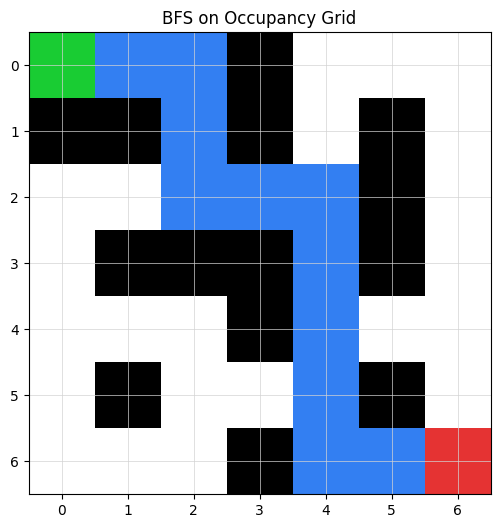

In [3]:
path = bfs_grid(grid, start, goal, connectivity=4)

print(f'Path found: {path is not None}')
if path is not None:
    print(f'Path length (edges): {len(path) - 1}')
    print(f'Path nodes: {path}')
else:
    print('No feasible path found.')

draw_result(grid, start, goal, path)

## 4) Explore Interactively

The widgets let you compare maps and connectivity options quickly.

Try changing the map and see how the path changes without editing the algorithm itself.

## 2) Run a Fixed Example

This cell runs BFS on one fixed grid.

What to observe:

- Which cells are obstacles.
- How the path goes around the blocked cells.
- How changing `connectivity` from `4` to `8` changes the result.

Try editing the grid values and rerunning the cell to see how the path changes.

In [4]:
# Interactive controls (editable in notebook)
map_cases = {
    'Narrow Corridor': {
        'grid': np.array([
            [0, 0, 0, 1, 0, 0, 0],
            [1, 1, 0, 1, 0, 1, 0],
            [0, 0, 0, 0, 0, 1, 0],
            [0, 1, 1, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (0, 6),
    },
    'Open Field': {
        'grid': np.array([
            [0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
}

map_selector = widgets.Dropdown(
    options=list(map_cases.keys()),
    value='Narrow Corridor',
    description='Map',
)

connectivity_selector = widgets.ToggleButtons(
    options=[('4-neighbor', 4), ('8-neighbor', 8)],
    value=4,
    description='Connectivity',
)

output = widgets.Output()

def update_view(*_args):
    case = map_cases[map_selector.value]
    grid_local = case['grid']
    start_local = case['start']
    goal_local = case['goal']

    with output:
        output.clear_output(wait=True)
        path_local = bfs_grid(grid_local, start_local, goal_local, connectivity_selector.value)
        print(f'Path found: {path_local is not None}')
        if path_local is not None:
            print(f'Path length (edges): {len(path_local) - 1}')
        else:
            print('No feasible path found.')
        draw_result(grid_local, start_local, goal_local, path_local, title='BFS interactive view')

map_selector.observe(update_view, names='value')
connectivity_selector.observe(update_view, names='value')
display(widgets.VBox([map_selector, connectivity_selector, output]))
update_view()

## 3) Explore Interactively

This final section adds simple widgets so you can switch between map layouts and connectivity settings.

Use it to answer questions like:

- What happens when the map becomes more blocked?
- How does 8-neighbor motion change the path?
- When does BFS fail because no path exists?

This is a good place to experiment after you understand the basic code above.